# 01. Data preparation: validation, split and class weights

This notebook runs once. It checks every image file, looks at the class distribution, shows a handful of paintings per artist to confirm the labels look right, splits the data 70/15/15 with stratification, and computes class weights.

The output is three folders on disk (`dataset_split/train/`, `val/`, `test/`) with one subfolder per artist, plus `dataset_split/class_weights.json`. Because the split is committed to git, every member of the group trains and evaluates on the same images. That's what makes the model to model comparisons in notebook 06 actually fair.


In [1]:
import os, json, shutil, random, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

# Update DATASET_DIR to point at the local raw-data folder before running.
# The split folder is portable and lives next to the notebooks.
DATASET_DIR = os.path.join("..", "data", "wikiart")
SPLIT_DIR   = os.path.join("..", "dataset_split")
SEED        = 42

random.seed(SEED)
np.random.seed(SEED)

dataset_path = Path(DATASET_DIR)


## 1. Image validation

We walk every file in every artist folder and drop anything PIL can't open. Corrupt or truncated files are rare in this dataset, but a single one is enough to crash training halfway through an epoch. Filtering up front is much cheaper than catching errors inside the pipeline later.


In [2]:
class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
num_classes = len(class_names)

valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
all_paths, all_labels = [], []
skipped = 0

for cls in class_names:
    for fpath in (dataset_path / cls).iterdir():
        if fpath.suffix.lower() not in valid_extensions:
            skipped += 1
            continue
        try:
            with Image.open(fpath) as img:
                img.verify()
            all_paths.append(str(fpath))
            all_labels.append(cls)
        except Exception:
            skipped += 1

print(f"Valid: {len(all_paths)} images across {num_classes} classes")
if skipped:
    print(f"Skipped: {skipped}")


Valid: 13340 images across 23 classes


## 2. Class distribution

A bar chart of how many paintings each artist has, with the mean shown as a reference line. The biggest class has about 4x more images than the smallest. That's enough imbalance to matter, so we handle it two ways downstream: class weights during training, and macro F1 alongside accuracy at evaluation time. A model that only does well on the big classes won't be able to hide behind a nice Top-1.


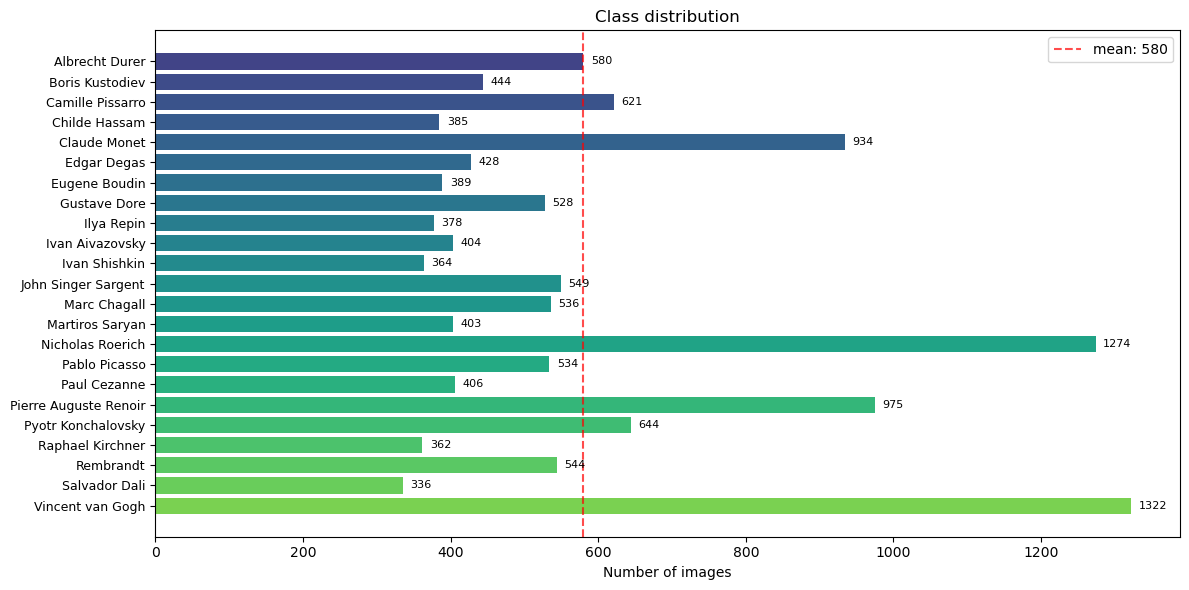

Imbalance ratio: 3.93x


In [3]:
counts = Counter(all_labels)
counts_list = [counts[cls] for cls in class_names]

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, num_classes))
bars = ax.barh(range(num_classes), counts_list, color=colors)
ax.set_yticks(range(num_classes))
ax.set_yticklabels([c.replace("_", " ") for c in class_names], fontsize=9)
ax.set_xlabel("Number of images")
ax.set_title("Class distribution")
ax.invert_yaxis()
for bar, count in zip(bars, counts_list):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(count), va="center", fontsize=8)
mean_count = np.mean(counts_list)
ax.axvline(mean_count, color="red", linestyle="--", alpha=0.7, label=f"mean: {mean_count:.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Imbalance ratio: {max(counts_list)/min(counts_list):.2f}x")


## 3. Sample images per artist

Four images per artist. The point is to eyeball whether the labels look right and to get a feel for which classes are going to be hard.

This grid also explains why we keep augmentation mild. Strong rotations or heavy colour jitter would wash out brushstroke and palette cues, and those cues are exactly what tell Monet apart from Pissarro. Augmentation should hide nothing the model needs.


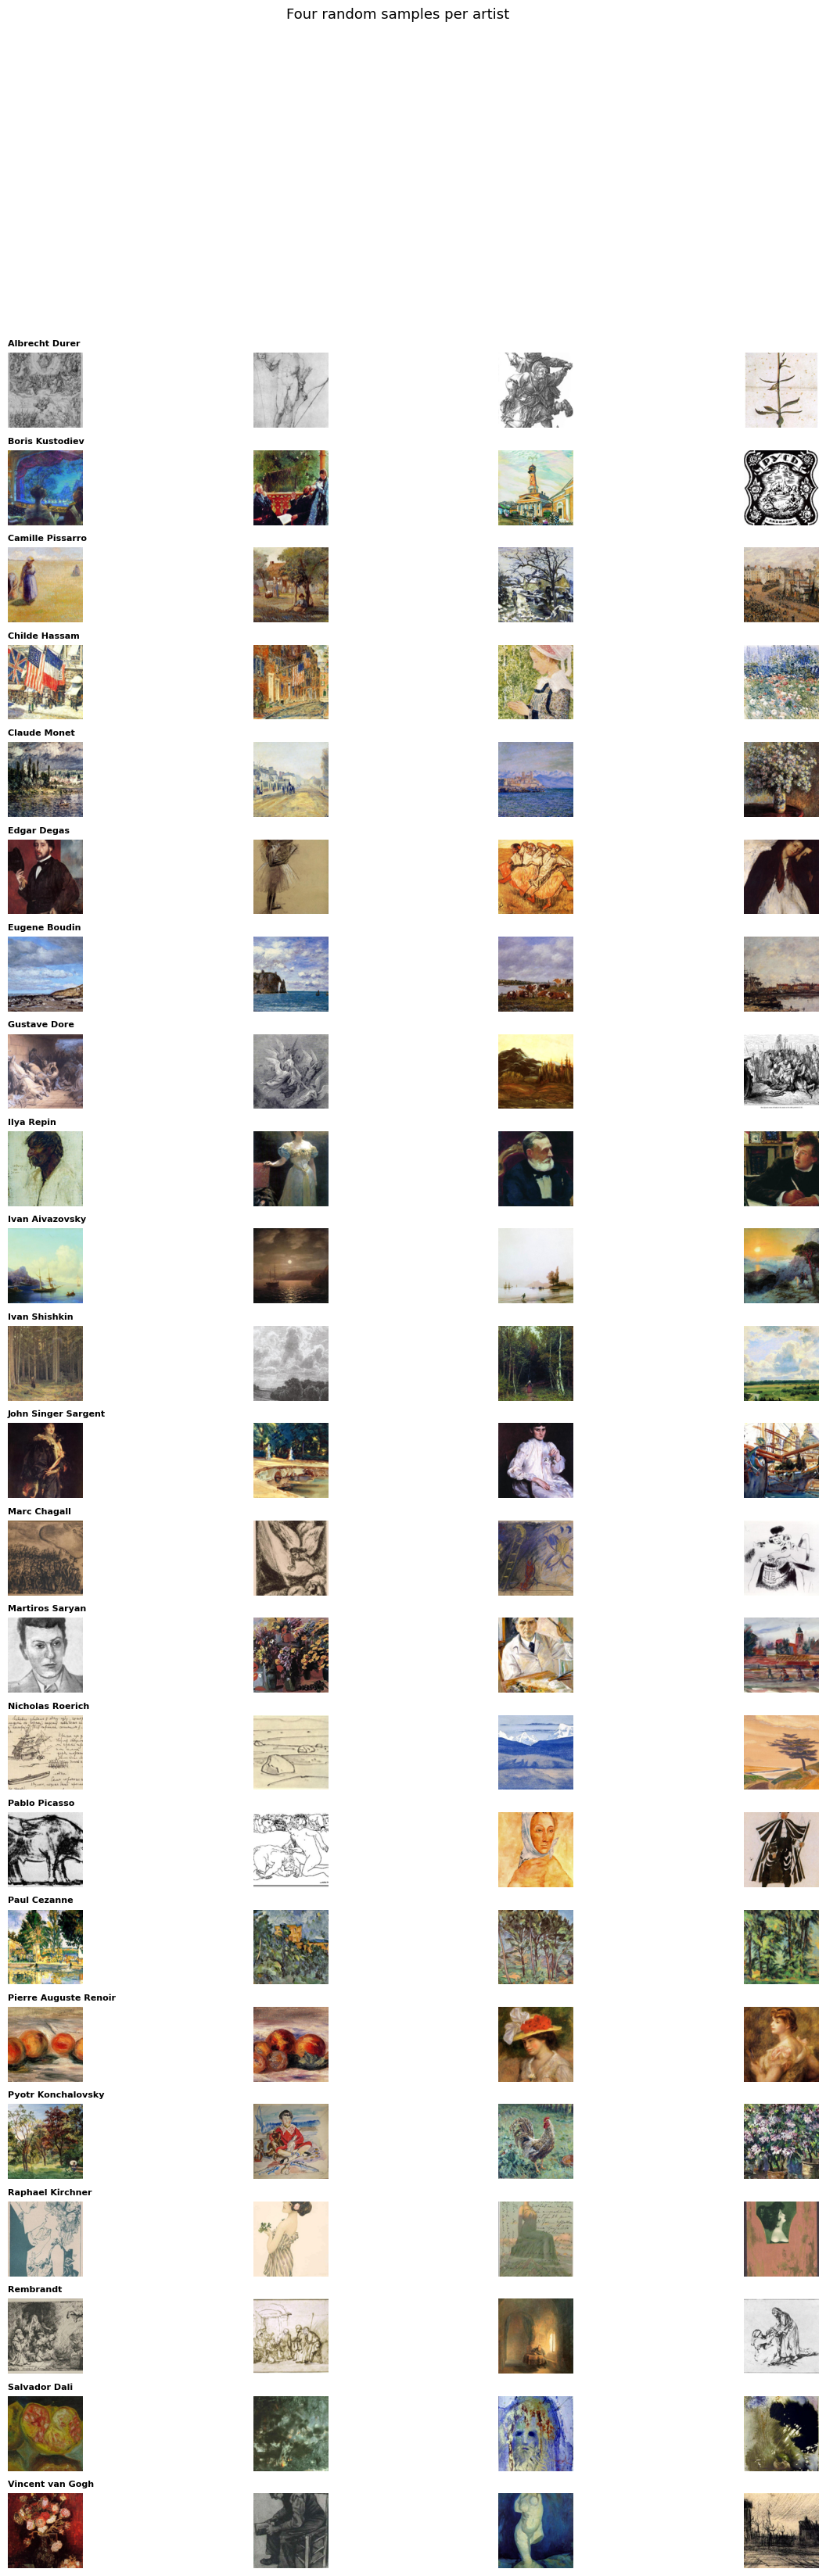

In [4]:
n_samples = 4
fig = plt.figure(figsize=(16, num_classes * 1.6))
gs = gridspec.GridSpec(num_classes, n_samples, hspace=0.3, wspace=0.05)

class_path_map = {cls: [] for cls in class_names}
for p, lbl in zip(all_paths, all_labels):
    class_path_map[lbl].append(p)

for row, cls in enumerate(class_names):
    samples = random.sample(class_path_map[cls], min(n_samples, len(class_path_map[cls])))
    for col, img_path in enumerate(samples):
        ax = fig.add_subplot(gs[row, col])
        img = Image.open(img_path).convert("RGB").resize((128, 128))
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_title(cls.replace("_", " "), fontsize=8, loc="left", fontweight="bold")

plt.suptitle("Four random samples per artist", fontsize=13, y=1.0)
plt.tight_layout()
plt.show()


## 4. Watermarks and signatures

WikiArt scans sometimes carry the painter's signature on the canvas, and occasionally a museum watermark or catalogue stamp in a corner. This matters because a classifier can easily learn to spot the signature instead of the painting. Test accuracy goes up, real-world accuracy collapses on anything without the mark.

The cell below shows the bottom 20% strip of one painting per artist (where signatures and captions usually sit) next to the full image. If the signatures turn out to be systematic, we mask them. Otherwise we leave the inputs as they are.


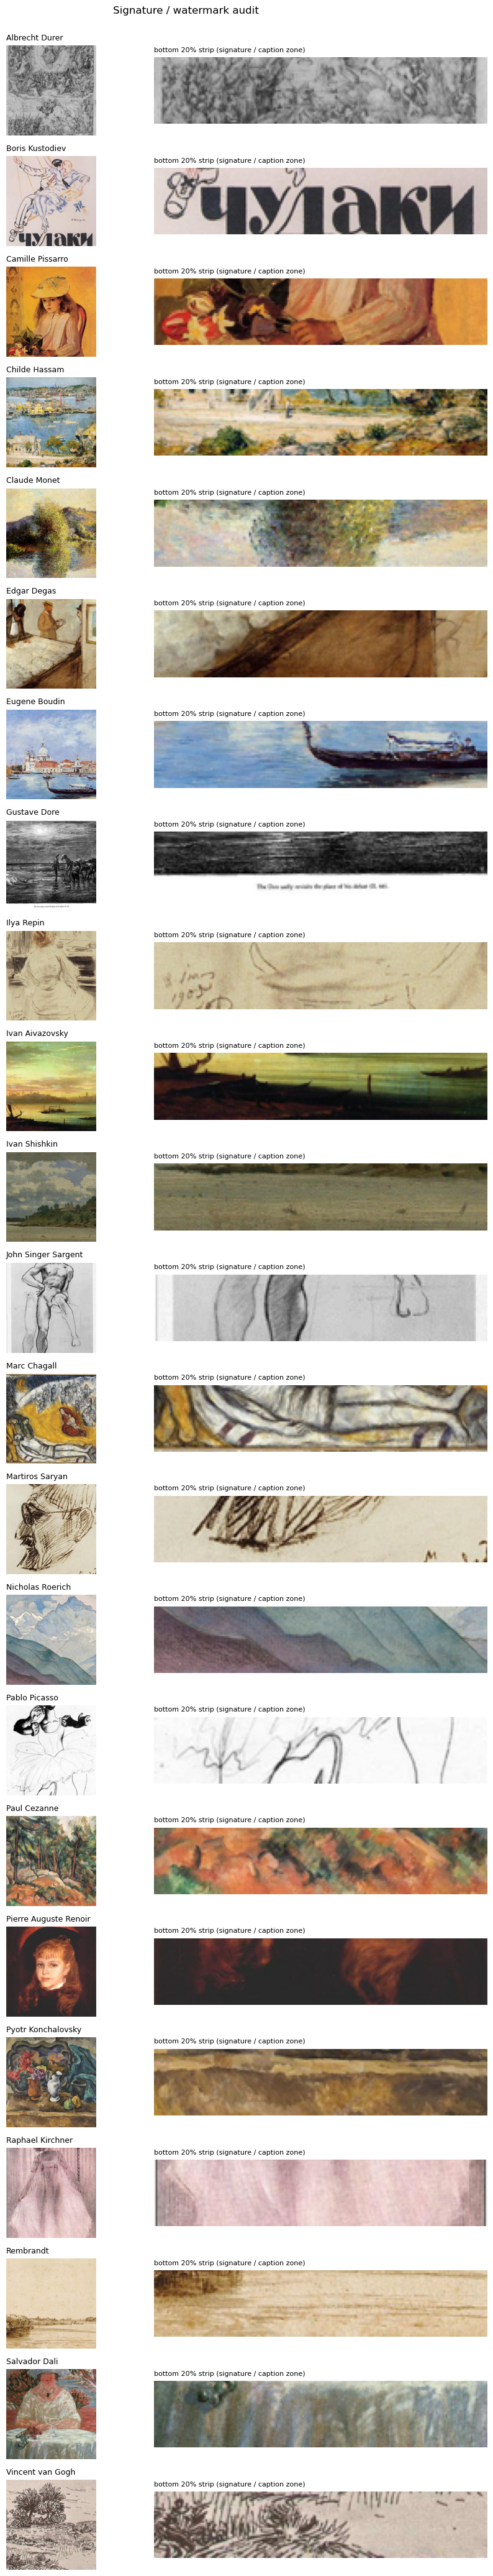

In [5]:
# Visual audit: show the bottom strip (signature / watermark zone) of one
# sample per artist next to the full painting.
rng = random.Random(SEED)
fig, axes = plt.subplots(num_classes, 2, figsize=(10, num_classes * 1.8))

for row, cls in enumerate(class_names):
    sample = rng.choice(class_path_map[cls])
    img = Image.open(sample).convert("RGB")
    w, h = img.size
    strip = img.crop((0, int(0.80 * h), w, h))   # bottom 20%

    axes[row, 0].imshow(img.resize((200, 200)))
    axes[row, 0].axis("off")
    axes[row, 0].set_title(cls.replace("_", " "), fontsize=9, loc="left")

    axes[row, 1].imshow(strip.resize((200, 40)))
    axes[row, 1].axis("off")
    axes[row, 1].set_title("bottom 20% strip (signature / caption zone)", fontsize=8, loc="left")

plt.suptitle("Signature / watermark audit", fontsize=12, y=1.0)
plt.tight_layout()
plt.show()


### Audit conclusion

The signatures are not universal (many canvases have none), not in a consistent corner, and they look different across scans of the same artist. For a model to exploit them as a shortcut it would have to learn a separate signature style per artist, which is about as hard as learning the painting style itself. Museum watermarks are rare.

So we leave the inputs untouched and move on.


## 5. Stratified 70/15/15 split

A two step stratified split keeps each artist's proportion steady across train, validation and test. Files are copied into `dataset_split/{train,val,test}/<artist>/`. That way the model notebooks just point `keras.utils.image_dataset_from_directory` at each split and get going.


In [ ]:
# 70 / 15 / 15 stratified split. sklearn's train_test_split only cuts into
# two pieces, so we call it twice: first 70/30, then 50/50 of the 30%.
# stratify= preserves per-class proportions in every output, which matters
# under our 3.94x imbalance (without it, a small class like Salvador Dali
# could end up 3% of train and 1% of val by unlucky sampling).

# 1st split: 70% train, 30% pooled temp. random_state=SEED makes this
# reproducible across every group member's laptop.
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.30, random_state=SEED, stratify=all_labels,
)

# 2nd split: the 30% pool, 50/50 → 15% val, 15% test.
# stratify=temp_labels (NOT all_labels) — we're partitioning the pool, so
# the stratification constraint must come from the pool itself.
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50, random_state=SEED, stratify=temp_labels,
)

print(f"Train: {len(train_paths)}    Val: {len(val_paths)}    Test: {len(test_paths)}")

# Materialise on disk as dataset_split/{split}/{Artist}/{file}.jpg — the
# layout image_dataset_from_directory expects (folder name = class name).
for split_name, paths, labels in [
    ("train", train_paths, train_labels),
    ("val",   val_paths,   val_labels),
    ("test",  test_paths,  test_labels),
]:
    for src_path, label in zip(paths, labels):
        dest_dir = os.path.join(SPLIT_DIR, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)                # idempotent
        dest_path = os.path.join(dest_dir, os.path.basename(src_path))
        # Skip if already copied — lets the cell resume after an interrupt
        # without redoing the I/O. Assumes source files are read-only.
        if not os.path.exists(dest_path):
            # copy2 preserves mtime/mode; plain copy does not.
            shutil.copy2(src_path, dest_path)

# Sanity check: recount on disk in case anything silently went wrong
# (disk full, permission denied, case-insensitive FS merging two files).
for split_name in ["train", "val", "test"]:
    split_path = Path(SPLIT_DIR) / split_name
    n_files   = sum(1 for p in split_path.rglob("*") if p.is_file())
    n_classes = len(list(split_path.iterdir()))
    print(f"  {split_name}/: {n_files} files, {n_classes} classes")

## 6. Class weights

Computed on the training split only, with scikit-learn's `compute_class_weight("balanced", ...)`. Each class gets an inverse frequency weight, so a painting from a small class contributes more to the loss than one from a large class. This is what stops the model from ignoring the minority artists to optimise for the popular ones. We dump the result to JSON and every training notebook reads it back.


In [ ]:
# Inverse-frequency class weights, computed on the TRAINING split only
# (val/test would leak held-out info). Written to a shared JSON so every
# training notebook uses identical weights → differences in results are
# model-driven, not weight-tuning-driven.

# String labels -> int indices. sorted() order here matches the alphabetical
# order image_dataset_from_directory uses, so the indices align with what
# Keras sees at load time (getting this wrong silently assigns weights to
# the wrong classes).
train_label_indices = [class_names.index(lbl) for lbl in train_labels]

# Formula: weight_c = n_samples / (n_classes * n_samples_in_c).
# Under-represented classes get weight > 1; over-represented get < 1.
# Weights sum to n_classes (mean = 1), so absolute scale doesn't matter.
weights = compute_class_weight("balanced",
                               classes=np.arange(num_classes),
                               y=train_label_indices)

# int(k): np.int64 isn't JSON-serialisable. round(4): four decimals is
# plenty and keeps the file small.
class_weight_dict = {int(k): round(float(v), 4) for k, v in enumerate(weights)}

os.makedirs(SPLIT_DIR, exist_ok=True)
with open(os.path.join(SPLIT_DIR, "class_weights.json"), "w") as f:
    json.dump(class_weight_dict, f)

# Spot-check: highest weight should be the rarest class (Salvador Dali),
# lowest the most common (Van Gogh). If not, label alignment is wrong.
sorted_w = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)
print("Highest weight (most underrepresented):")
for idx, w in sorted_w[:3]:
    print(f"  {class_names[idx]:30s}  {w:.4f}")
print("Lowest weight (most overrepresented):")
for idx, w in sorted_w[-3:]:
    print(f"  {class_names[idx]:30s}  {w:.4f}")